# Redução de Dimensionalidade com scikit-learn

Neste notebook, exploraremos táticas de redução de dimensionalidade, que ajudam a simplificar os dados para facilitar a análise e a visualização. Vamos abordar:

1. **Análise de Componentes Principais (PCA)** para visualização em 2D.
2. **Seleção de características com SelectKBest** para escolher as variáveis mais relevantes.

# Importando bibliotecas

In [1]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos

In [2]:
sns.set(style="darkgrid")

# Carregando o conjunto de dados Iris

In [3]:
iris = load_iris()
X = iris.data
y = iris.target

# Criando um DataFrame para facilitar a manipulação

In [4]:
df = pd.DataFrame(X, columns=iris.feature_names)
df['Target'] = y

# Visualizando as primeiras linhas do dataset

In [5]:
print("\nConjunto de dados Iris:")
print(df.head())


Conjunto de dados Iris:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Target  
0       0  
1       0  
2       0  
3       0  
4       0  


# 1. Análise de Componentes Principais (PCA)

## Aplicando PCA para reduzir as dimensões para 2 componentes

In [6]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)


# Criando um DataFrame para visualização

In [7]:
pca_df = pd.DataFrame(X_pca, columns=['Componente 1', 'Componente 2'])
pca_df['Target'] = y

# Visualizando os dados reduzidos

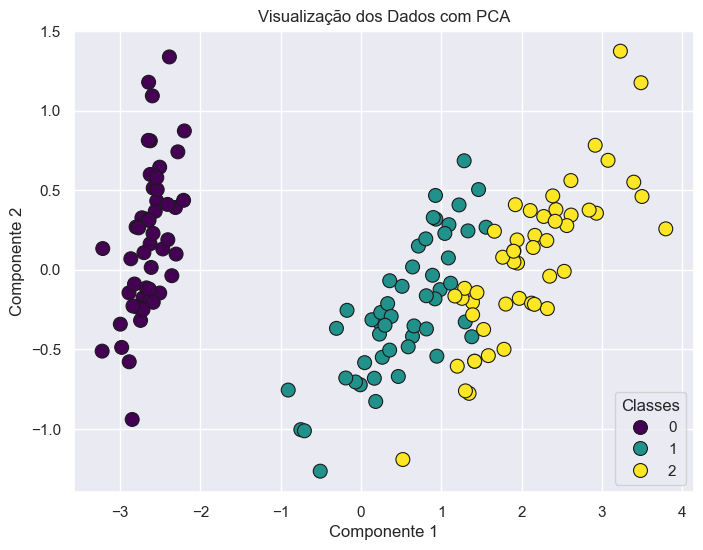

In [8]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_df, x='Componente 1', y='Componente 2', hue='Target', palette='viridis', s=100, edgecolor='k')
plt.title("Visualização dos Dados com PCA")
plt.xlabel("Componente 1")
plt.ylabel("Componente 2")
plt.legend(title="Classes", loc='best')
plt.show()


## Explicando a variância dos componentes principais

In [9]:
print("\nVariância explicada por cada componente principal:")
print(pca.explained_variance_ratio_)


Variância explicada por cada componente principal:
[0.92461872 0.05306648]


# 2. Seleção de Características com SelectKBest

## Selecionando as 2 melhores características baseadas na ANOVA

In [10]:
selector = SelectKBest(score_func=f_classif, k=2)
X_new = selector.fit_transform(X, y)

# Mostrando os scores das características

In [11]:
print("\nScores das características:")
scores = pd.DataFrame({'Feature': iris.feature_names, 'Score': selector.scores_})
scores = scores.sort_values(by='Score', ascending=False)
print(scores)


Scores das características:
             Feature        Score
2  petal length (cm)  1180.161182
3   petal width (cm)   960.007147
0  sepal length (cm)   119.264502
1   sepal width (cm)    49.160040


# Criando um DataFrame com as características selecionadas

In [12]:
selected_features = selector.get_feature_names_out()
print(f"\nCaracterísticas Selecionadas: {selected_features}")


Características Selecionadas: ['x2' 'x3']


# Visualizando as características selecionadas

In [13]:
selected_df = pd.DataFrame(X_new, columns=selected_features)
selected_df['Target'] = y

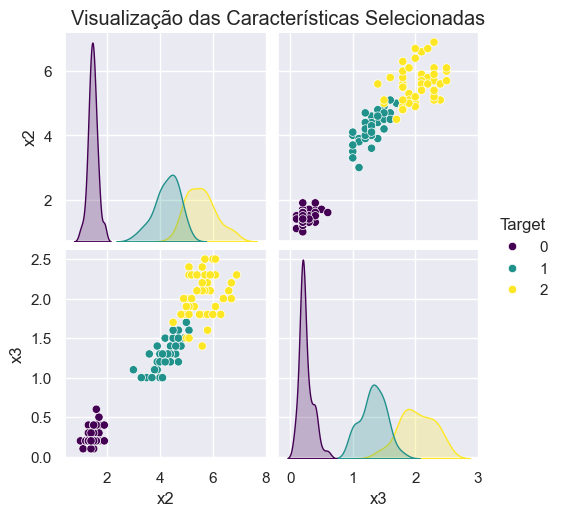

In [14]:
sns.pairplot(selected_df, hue='Target', palette='viridis', diag_kind='kde')
plt.suptitle("Visualização das Características Selecionadas", y=1.02)
plt.show()